In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
raw_data = pd.read_csv('./Bangalore_House_Price_data/Bengaluru_House_Data.csv')

In [3]:
df = raw_data.copy()

In [4]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [5]:
for key in df.keys():
    print(df[key].value_counts())
    print('-----------------------')

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
-----------------------
availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64
-----------------------
location
Whitefield                                         540
Sarjapur  Road                                     399
Electronic City                                    302
Kanakpura Road                                     273
Thanisandra                                        234
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage

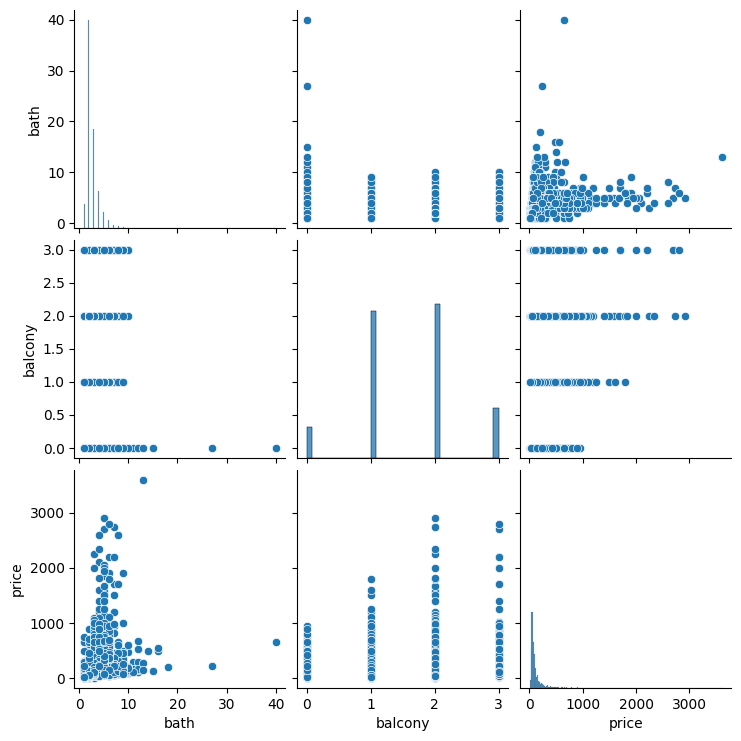

In [6]:
sns.pairplot(data=df)

<Axes: >

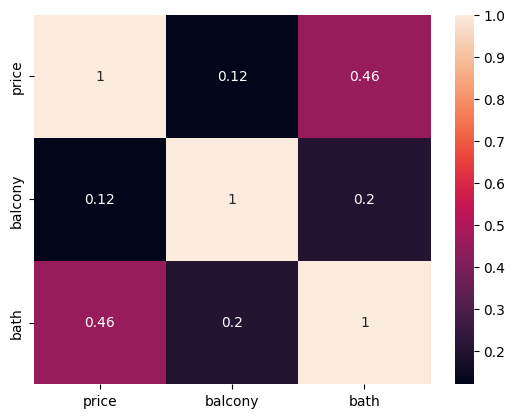

In [7]:
num_vars = ['price', 'balcony', 'bath']
sns.heatmap(data=df[num_vars].corr(), annot=True)

In [8]:
df.isnull().sum()
df.isnull().mean() * 100

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
dtype: float64

In [9]:
df2 = df.drop('society', axis=1)
df2.keys()

Index(['area_type', 'availability', 'location', 'size', 'total_sqft', 'bath',
       'balcony', 'price'],
      dtype='str')

In [10]:
df2.fillna({'balcony': df2['balcony'].mean()}, inplace=True)

df2.isnull().sum()

area_type        0
availability     0
location         1
size            16
total_sqft       0
bath            73
balcony          0
price            0
dtype: int64

In [11]:
df3 = df2.dropna().reset_index(drop=True)
df3.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [12]:
for key in df3.keys():
    print(df3[key].value_counts())
    print('-----------------------')

area_type
Super built-up  Area    8740
Built-up  Area          2410
Plot  Area              2009
Carpet  Area              87
Name: count, dtype: int64
-----------------------
availability
Ready To Move    10564
18-Dec             297
18-May             291
18-Apr             269
18-Aug             200
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 80, dtype: int64
-----------------------
location
Whitefield                                         534
Sarjapur  Road                                     392
Electronic City                                    302
Kanakpura Road                                     266
Thanisandra                                        233
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage

In [13]:
total_sqft_float = []
for str_val in df3['total_sqft']:
  try:
    total_sqft_float.append(float(str_val))
  except:
    try:
      temp = str_val.split('-')
      total_sqft_float.append((float(temp[0])+float(temp[-1]))/2) 
    except:
      total_sqft_float.append(np.nan)

df4 = df3.join(pd.DataFrame({'total_sqft_float': total_sqft_float}))

In [14]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 13246 entries, 0 to 13245
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         13246 non-null  str    
 1   availability      13246 non-null  str    
 2   location          13246 non-null  str    
 3   size              13246 non-null  str    
 4   total_sqft        13246 non-null  str    
 5   bath              13246 non-null  float64
 6   balcony           13246 non-null  float64
 7   price             13246 non-null  float64
 8   total_sqft_float  13200 non-null  float64
dtypes: float64(4), str(5)
memory usage: 931.5 KB


In [15]:
df4.isnull().sum()

area_type            0
availability         0
location             0
size                 0
total_sqft           0
bath                 0
balcony              0
price                0
total_sqft_float    46
dtype: int64

In [16]:
df5 = df4.dropna().reset_index(drop=True)
df5.info()

<class 'pandas.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         13200 non-null  str    
 1   availability      13200 non-null  str    
 2   location          13200 non-null  str    
 3   size              13200 non-null  str    
 4   total_sqft        13200 non-null  str    
 5   bath              13200 non-null  float64
 6   balcony           13200 non-null  float64
 7   price             13200 non-null  float64
 8   total_sqft_float  13200 non-null  float64
dtypes: float64(4), str(5)
memory usage: 928.3 KB


In [17]:
df5['size'].value_counts()

size
2 BHK         5192
3 BHK         4277
4 Bedroom      816
4 BHK          574
3 Bedroom      541
1 BHK          527
2 Bedroom      325
5 Bedroom      293
6 Bedroom      190
1 Bedroom      100
8 Bedroom       83
7 Bedroom       83
5 BHK           56
9 Bedroom       45
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            7
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
27 BHK           1
19 BHK           1
16 BHK           1
43 Bedroom       1
14 BHK           1
12 Bedroom       1
13 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [18]:
size_int = []
for str_val in df5['size']:
  temp=[]
  temp = str_val.split(" ")
  try:
    size_int.append(int(temp[0]))
  except:
    size_int.append(np.nan)

df6 = df5.join(pd.DataFrame({'bhk': size_int}))

df6.info()

<class 'pandas.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         13200 non-null  str    
 1   availability      13200 non-null  str    
 2   location          13200 non-null  str    
 3   size              13200 non-null  str    
 4   total_sqft        13200 non-null  str    
 5   bath              13200 non-null  float64
 6   balcony           13200 non-null  float64
 7   price             13200 non-null  float64
 8   total_sqft_float  13200 non-null  float64
 9   bhk               13200 non-null  int64  
dtypes: float64(4), int64(1), str(5)
memory usage: 1.0 MB


<Axes: xlabel='bhk', ylabel='total_sqft_float'>

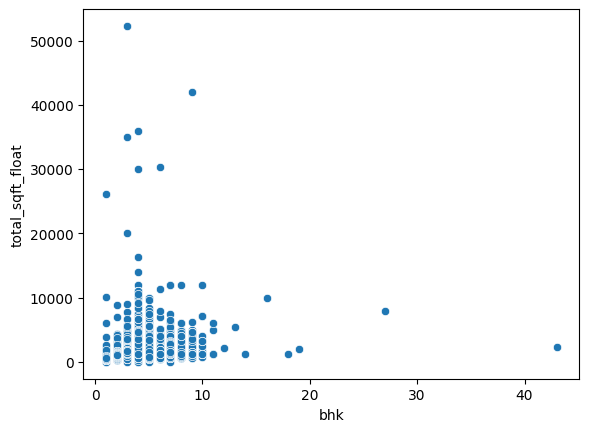

In [19]:
sns.scatterplot(data=df6, x='bhk', y='total_sqft_float')

In [20]:
df6[df6['total_sqft_float']/df6['bhk'] <= 350]

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,1020,6.0,1.584376,370.0,1020.0,6
26,Super built-up Area,Ready To Move,Electronic City,2 BHK,660,1.0,1.000000,23.1,660.0,2
29,Super built-up Area,Ready To Move,Electronic City,3 BHK,1025,2.0,1.000000,47.0,1025.0,3
35,Super built-up Area,21-Dec,Kanakpura Road,2 BHK,700,2.0,1.000000,36.0,700.0,2
45,Plot Area,Ready To Move,HSR Layout,8 Bedroom,600,9.0,1.584376,200.0,600.0,8
...,...,...,...,...,...,...,...,...,...,...
13161,Plot Area,Ready To Move,Margondanahalli,5 Bedroom,1375,5.0,1.000000,125.0,1375.0,5
13180,Plot Area,Ready To Move,Hosakerehalli,5 Bedroom,1500,6.0,2.000000,145.0,1500.0,5
13183,Plot Area,Ready To Move,Vidyaranyapura,5 Bedroom,774,5.0,3.000000,70.0,774.0,5
13186,Plot Area,Ready To Move,Rajarajeshwari Nagara,4 Bedroom,1200,5.0,1.584376,325.0,1200.0,4


In [21]:
df7 = df6[~(df6['total_sqft_float']/df6['bhk'] < 350)]
df7.info()

<class 'pandas.DataFrame'>
Index: 12106 entries, 0 to 13199
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         12106 non-null  str    
 1   availability      12106 non-null  str    
 2   location          12106 non-null  str    
 3   size              12106 non-null  str    
 4   total_sqft        12106 non-null  str    
 5   bath              12106 non-null  float64
 6   balcony           12106 non-null  float64
 7   price             12106 non-null  float64
 8   total_sqft_float  12106 non-null  float64
 9   bhk               12106 non-null  int64  
dtypes: float64(4), int64(1), str(5)
memory usage: 1.0 MB


In [22]:
df7['price_per_sqft'] = df7['price']*100000 / df7['total_sqft_float']  
df7.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0,2,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0,4,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0,3,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0,3,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0,2,4250.000000


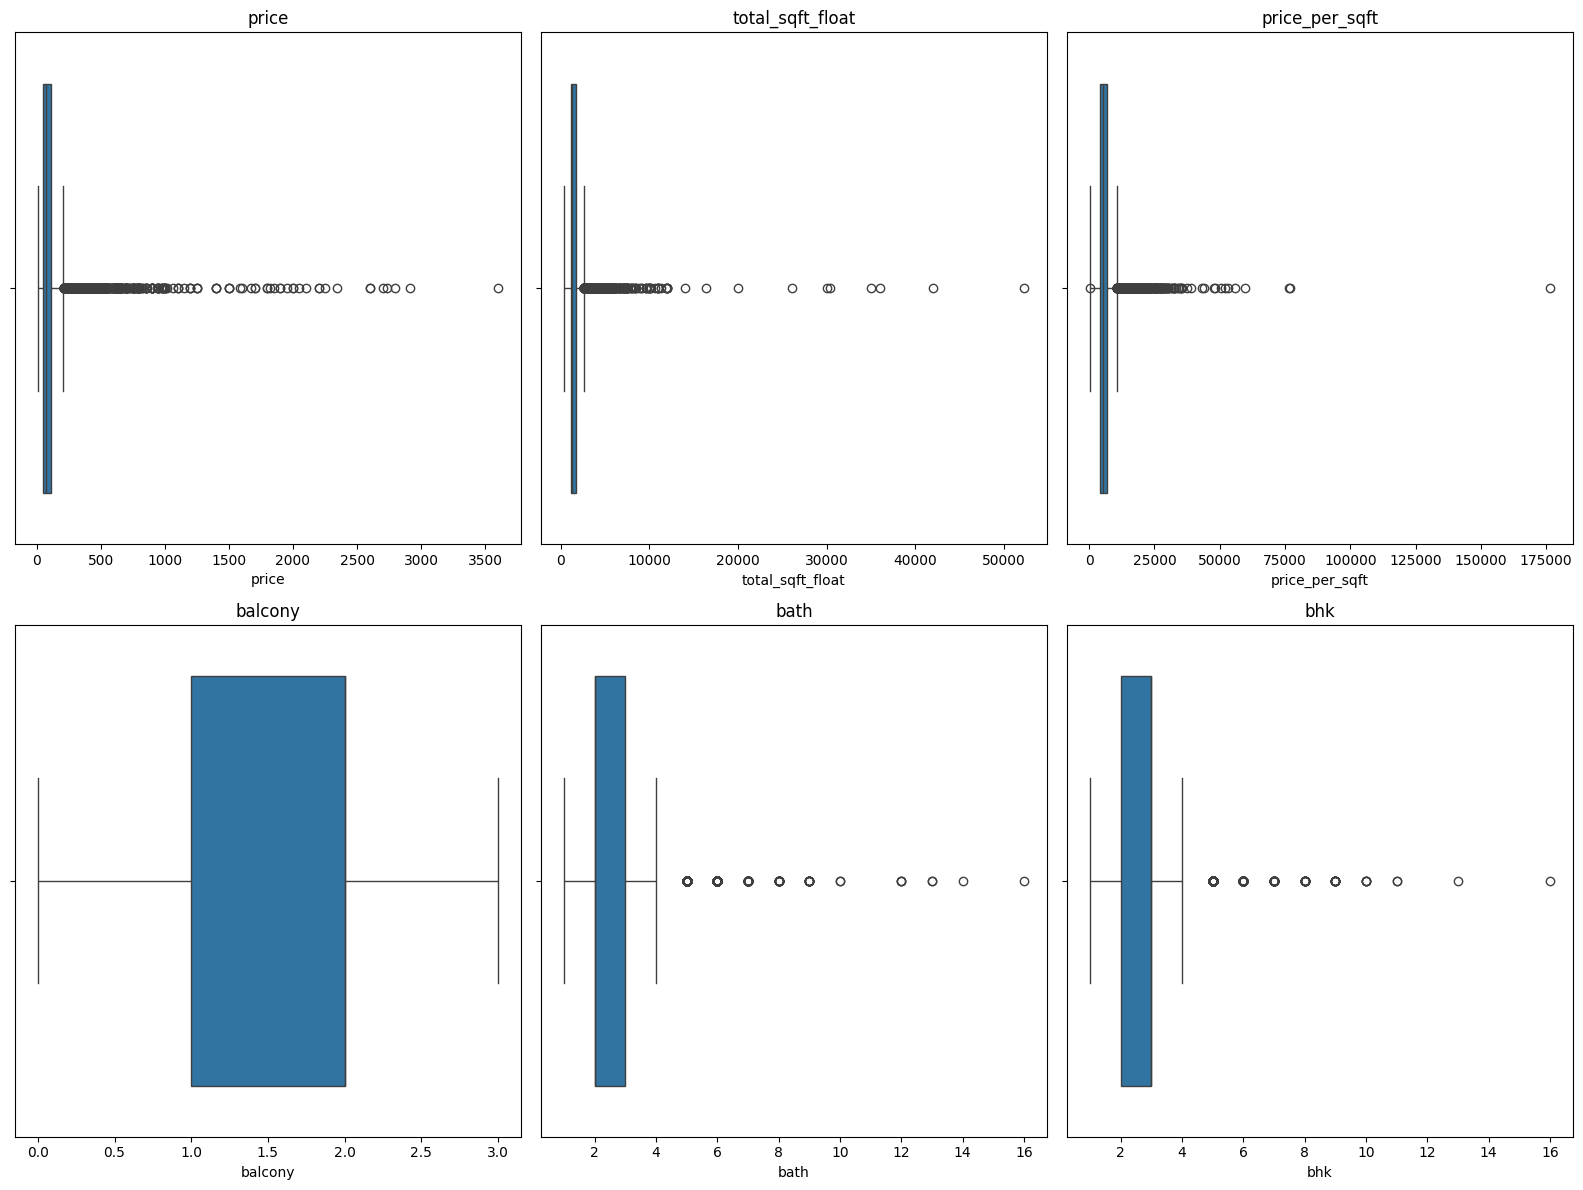

In [24]:
vars = ['price', 'total_sqft_float', 'price_per_sqft', 'balcony', 'bath', 'bhk']

plt.figure(figsize=(16,12))

for i, var in enumerate(vars, 1):
    plt.subplot(2, 3, i)  # 2 rows, 3 columns grid
    sns.boxplot(x=df7[var])
    plt.title(var)

plt.tight_layout()
plt.show()

In [32]:
df8 = df7.reset_index(drop=True)
df8.info()

<class 'pandas.DataFrame'>
RangeIndex: 12106 entries, 0 to 12105
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         12106 non-null  str    
 1   availability      12106 non-null  str    
 2   location          12106 non-null  str    
 3   size              12106 non-null  str    
 4   total_sqft        12106 non-null  str    
 5   bath              12106 non-null  float64
 6   balcony           12106 non-null  float64
 7   price             12106 non-null  float64
 8   total_sqft_float  12106 non-null  float64
 9   bhk               12106 non-null  int64  
 10  price_per_sqft    12106 non-null  float64
dtypes: float64(5), int64(1), str(5)
memory usage: 1.0 MB


In [55]:
def remove_pps_outliers(df: pd.DataFrame):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m=np.mean(subdf.price_per_sqft)
        st=np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft>(m-st))&(subdf.price_per_sqft<=(m+st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df9 = remove_pps_outliers(df8)
df9.info()


<class 'pandas.DataFrame'>
RangeIndex: 8888 entries, 0 to 8887
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         8888 non-null   str    
 1   availability      8888 non-null   str    
 2   location          8888 non-null   str    
 3   size              8888 non-null   str    
 4   total_sqft        8888 non-null   str    
 5   bath              8888 non-null   float64
 6   balcony           8888 non-null   float64
 7   price             8888 non-null   float64
 8   total_sqft_float  8888 non-null   float64
 9   bhk               8888 non-null   int64  
 10  price_per_sqft    8888 non-null   float64
dtypes: float64(5), int64(1), str(5)
memory usage: 763.9 KB


In [59]:
def remove_bhk_outliers(df: pd.DataFrame):
    exclude_indices = []
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk]={
                'mean':np.mean(bhk_df.price_per_sqft),
                'std':np.std(bhk_df.price_per_sqft),
                'count':bhk_df.shape[0]}
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats=bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices.extend(bhk_df[(bhk_df['price_per_sqft']) < stats['mean']].index.tolist())
    return df.drop(exclude_indices, axis='index').reset_index(drop=True)

df10 = remove_bhk_outliers(df9)
df10.info()


<class 'pandas.DataFrame'>
RangeIndex: 7194 entries, 0 to 7193
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         7194 non-null   str    
 1   availability      7194 non-null   str    
 2   location          7194 non-null   str    
 3   size              7194 non-null   str    
 4   total_sqft        7194 non-null   str    
 5   bath              7194 non-null   float64
 6   balcony           7194 non-null   float64
 7   price             7194 non-null   float64
 8   total_sqft_float  7194 non-null   float64
 9   bhk               7194 non-null   int64  
 10  price_per_sqft    7194 non-null   float64
dtypes: float64(5), int64(1), str(5)
memory usage: 618.4 KB


In [67]:
df11 = df10[df10['bath'] < df10.bhk + 2].reset_index(drop=True)

df11.info()

<class 'pandas.DataFrame'>
RangeIndex: 7120 entries, 0 to 7119
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         7120 non-null   str    
 1   availability      7120 non-null   str    
 2   location          7120 non-null   str    
 3   size              7120 non-null   str    
 4   total_sqft        7120 non-null   str    
 5   bath              7120 non-null   float64
 6   balcony           7120 non-null   float64
 7   price             7120 non-null   float64
 8   total_sqft_float  7120 non-null   float64
 9   bhk               7120 non-null   int64  
 10  price_per_sqft    7120 non-null   float64
dtypes: float64(5), int64(1), str(5)
memory usage: 612.0 KB


In [70]:
df12 = df11.drop(df11.columns[[0, 1, 2, 3, 4]], axis=1)
df12.info()

<class 'pandas.DataFrame'>
RangeIndex: 7120 entries, 0 to 7119
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bath              7120 non-null   float64
 1   balcony           7120 non-null   float64
 2   price             7120 non-null   float64
 3   total_sqft_float  7120 non-null   float64
 4   bhk               7120 non-null   int64  
 5   price_per_sqft    7120 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 333.9 KB


In [71]:
df12.to_csv('./clean_data.csv', index=False)